# A galactic-binary segment for turntable

This notebook plugs a **real LISA source-class sampler** into the turntable
`Wheel`. To make it obvious *what is turntable and what is not*, everything that
is **not** turntable — the GBGPU waveform helpers, the LISA noise model, the data
injector, and the `GBSegment` itself — lives in a separate module,
[`gb_model.py`](gb_model.py). This notebook only:

1. imports turntable's `Residuals` and `Wheel`,
2. imports the model pieces from `gb_model`,
3. builds the dataset, wraps it in a `Residuals`, runs it through a `Wheel`, and
   reads the result back.

So every turntable touchpoint is visible here; the physics is behind the import.

- **waveforms** — [GBGPU](https://github.com/mikekatz04/GBGPU) (`master`), narrowband TDI;
- **sampler** — [Eryn](https://github.com/mikekatz04/Eryn), inside the segment;
- **noise** — fixed LISA sensitivity, carried on `Residuals.noise`, consumed by
  the segment via `residual.noise_psd()`.

> **Requires** the LISA stack (`gbgpu`, `eryn`, `lisaanalysistools`) in the same
> env as `turntable` — the conda env, not turntable's core `.venv`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# turntable — the orchestration layer
from turntable import Residuals, Wheel

# everything that is NOT turntable (see gb_model.py)
from gb_model import FixedLISANoise, GBSegment, inject_gb, waveform

/Users/aaron/miniconda3/envs/turntable/lib/python3.14/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


## 1. Define the dataset

turntable's frequency-domain convention is the one-sided rfft grid of the
underlying time series (`n_samples` counts *time-domain* samples; each tdi array
has length `n_samples // 2 + 1`).

In [2]:
dt = 15.0
N_time = 2 ** 19                      # time-domain samples -> pins Tobs, df
Tobs = N_time * dt                    # ~91 days
df = 1.0 / Tobs
freqs = np.fft.rfftfreq(N_time, dt)
CHANS = ("A", "E")
NB = 128                              # GBGPU template band width (bins)

TRUTH = np.array([2.0e-22, 3.0e-3, 1.0e-16, 0.7])          # amp, f0, fdot, phi0
ANGLES = (0.9, 1.3, 2.1, 0.4)                              # iota, psi, lam, beta  (fixed)
PARAMS = ["amp", "f0", "fdot", "phi0"]
print(f"Tobs={Tobs/86400:.0f} d, df={df:.2e} Hz, grid={freqs.size} bins")

Tobs=91 d, df=1.27e-07 Hz, grid=262145 bins


## 2. Noise model + injected data (both from `gb_model`)

`FixedLISANoise` and `inject_gb` are user code. `inject_gb` returns the raw
channel arrays; **wrapping them in a `Residuals` is the turntable step** — and it
is where the fixed noise gets attached so the segment can read it back.

In [3]:
noise = FixedLISANoise()
data, info = inject_gb(TRUTH, ANGLES, Tobs, dt, N_time, CHANS, noise, NB=NB, seed=42)
print(f"injected GB at f0={TRUTH[1]} Hz, bins {info['band']}, optimal SNR={info['snr']:.1f}")

# --- turntable: the data contract ---
observed = Residuals(
    tdi=data, sample_rate=1.0 / dt, n_samples=N_time, channels=CHANS,
    tdi_generation="2.0", observable="fractional_frequency",
    domain="frequency", noise=noise)          # epoch defaults to 0.0

injected GB at f0=0.003 Hz, bins slice(23529, 23657, None), optimal SNR=64.3


## 3. Run the model through turntable

Register a `GBSegment` on a `Wheel` and run. The segment reads channels, the
grid, and the noise (`residual.noise_psd()`) off the residual the Wheel hands
it — nothing is passed in from here except the residual itself.

In [4]:
BOUNDS = [[0.3 * TRUTH[0], 3.0 * TRUTH[0]],
          [TRUTH[1] - 30 * df, TRUTH[1] + 30 * df],
          [0.0, 3.0e-16],
          [0.0, 2 * np.pi]]

# MCMC sampling budget: total posterior samples = n_walkers * steps_per_sweep * n_sweeps
n_walkers, steps_per_sweep, n_sweeps = 40, 200, 12
seg = GBSegment(init=TRUTH, bounds=BOUNDS, angles=ANGLES,
                n_walkers=n_walkers, steps_per_sweep=steps_per_sweep)

wheel = Wheel(observed)          # turntable
wheel.add(seg)                   # turntable

def report(it, w):
    p = seg._p
    print(f"  sweep {it+1:2d}: amp={p[0]:.3e}  f0={p[1]:.9f}  fdot={p[2]:.3e}  phi0={p[3]:.3f}")

total = n_walkers * steps_per_sweep * n_sweeps
print(f"running the Wheel: {total:,} GB samples "
      f"({n_walkers} walkers x {steps_per_sweep} steps x {n_sweeps} sweeps), "
      f"noise via residual.noise_psd ...")
wheel.run(n_sweeps, on_sweep=report)     # turntable drives seg.step each sweep

running the Wheel: 96,000 GB samples (40 walkers x 200 steps x 12 sweeps), noise via residual.noise_psd ...


  sweep  1: amp=2.035e-22  f0=0.003000015  fdot=1.360e-16  phi0=0.685


  sweep  2: amp=2.045e-22  f0=0.003000015  fdot=1.482e-16  phi0=0.683


  sweep  3: amp=2.003e-22  f0=0.003000024  fdot=1.681e-16  phi0=0.692


  sweep  4: amp=2.006e-22  f0=0.003000025  fdot=1.557e-16  phi0=0.681


...

  sweep  8: amp=1.998e-22  f0=0.003000024  fdot=1.637e-16  phi0=0.696


  sweep  9: amp=2.001e-22  f0=0.003000024  fdot=1.828e-16  phi0=0.691


  sweep 10: amp=1.999e-22  f0=0.003000025  fdot=1.546e-16  phi0=0.687


  sweep 11: amp=2.003e-22  f0=0.003000025  fdot=1.469e-16  phi0=0.689


  sweep 12: amp=2.001e-22  f0=0.003000024  fdot=1.569e-16  phi0=0.698


## 4. Recovery

The posterior (half the chain after burn-in) sits within ~1σ of the injection.
`fdot` is intrinsically weakly constrained over 91 days. Turn the sampling
budget up or down with `n_walkers`/`steps_per_sweep`/`n_sweeps` above.

In [5]:
post = seg.chain[len(seg.chain) // 2:]        # drop first-half burn-in
print("posterior mean +/- std vs truth:")
for i, p in enumerate(PARAMS):
    m, s = post[:, i].mean(), post[:, i].std()
    z = (m - TRUTH[i]) / s if s else 0.0
    print(f"  {p:5s}: {m:.6e} +/- {s:.2e}   truth {TRUTH[i]:.6e}   ({z:+.1f} sigma)")

posterior mean +/- std vs truth:
  amp  : 2.000240e-22 +/- 3.22e-23   truth 2.000000e-22   (+0.0 sigma)
  f0   : 3.000024e-03 +/- 1.05e-07   truth 3.000000e-03   (+0.2 sigma)
  fdot : 1.560513e-16 +/- 8.92e-17   truth 1.000000e-16   (+0.6 sigma)
  phi0 : 6.896237e-01 +/- 2.73e-02   truth 7.000000e-01   (-0.4 sigma)


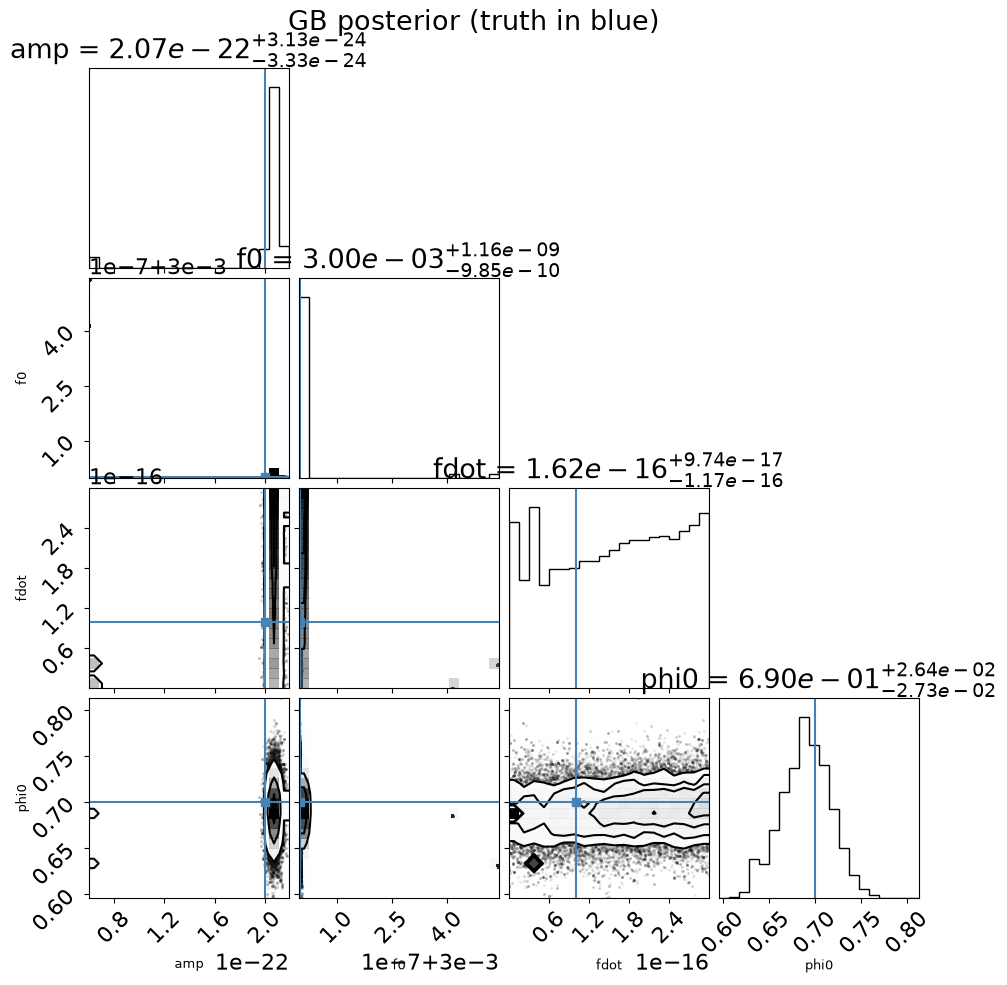

In [6]:
import corner
fig = corner.corner(post, labels=PARAMS, truths=TRUTH, show_titles=True,
                    title_fmt=".2e", label_kwargs={"fontsize": 9})
fig.suptitle("GB posterior (truth in blue)", y=1.02)
plt.show()

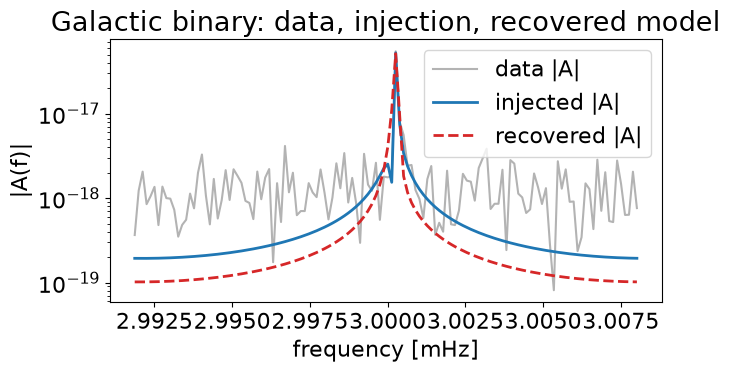

In [7]:
band = info["band"]
rsi, rhA, rhE = waveform(post.mean(0), ANGLES, Tobs, dt, NB)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(freqs[band] * 1e3, np.abs(observed.tdi["A"][band]), color="0.7", label="data |A|")
ax.semilogy(freqs[band] * 1e3, np.abs(info["signal"]["A"][band]), "C0", lw=2, label="injected |A|")
ax.semilogy(freqs[rsi:rsi + NB] * 1e3, np.abs(rhA), "C3--", lw=2, label="recovered |A|")
ax.set_xlabel("frequency [mHz]")
ax.set_ylabel("|A(f)|")
ax.legend()
ax.set_title("Galactic binary: data, injection, recovered model")
plt.tight_layout()
plt.show()

## Where next

- **All eight parameters** — enlarge `init`/`BOUNDS`/`ANGLES` (in `gb_model` the
  angles are held fixed) to sample the sky/orientation too.
- **A handful of sources** — register several `GBSegment`s (each its own band and
  Eryn sampler) on one `Wheel`. Then the ledger earns its keep: the Wheel hands each GB the data
  minus every *other* GB's current model — the blocked-Gibbs
  global fit turntable orchestrates.
- **Sampled noise** — swap `FixedLISANoise` for a noise *segment* that returns
  the residual with an updated `noise`; the GB segment already re-reads
  `residual.noise_psd()` each `step`, so it tracks it for free.